# Phase 2 - Feature Engineering & Imbalance Handling

This notebook is **deliberately thin**: all feature logic lives in reusable modules
under [`src/`](../src), and the notebook just orchestrates them.

- **Feature engineering** -> [`src/features.py`](../src/features.py) (`FeatureEngineer`)
- **Chronological val split** -> [`src/data.py`](../src/data.py)
- **Imbalance comparison** -> [`src/imbalance.py`](../src/imbalance.py)
- **Artifact persistence** -> [`src/artifacts.py`](../src/artifacts.py)

**Rules honoured throughout:** no random splitting (time-based only), no future
leakage (history features use *past* rows only; encoders fit on **train only**),
SMOTE applied **only on the training fold**, and **PR-AUC** is the headline metric
(accuracy is intentionally ignored).

In [1]:
import sys, os
sys.path.append(os.path.abspath("../src"))  # import the reusable modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data import load_processed_splits, chronological_val_split
from features import FeatureEngineer, transform_with_history
from imbalance import (
    compute_scale_pos_weight, train_class_weight, train_resampled,
    comparison_table, pick_best,
)
from artifacts import save_phase2_artifacts

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 4)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
RANDOM_STATE = 42

## 1. Load the Phase-1 chronological splits and carve a validation set

Phase 1 gave us `train` / `test`. The task asks us to *choose* the imbalance
strategy on **validation PR-AUC** while keeping `test` as an untouched final
hold-out - so we take the **last 15% of train, by time**, as validation. No
shuffling: the validation window is strictly later than the fit window.

In [2]:
train, test = load_processed_splits()

# Chronological validation split (NO random shuffle).
fit_df, val_df = chronological_val_split(train, val_frac=0.15)

print(f"fit  : {len(fit_df):,} rows  "
      f"({fit_df['trans_date_trans_time'].min().date()} -> {fit_df['trans_date_trans_time'].max().date()})")
print(f"val  : {len(val_df):,} rows  "
      f"({val_df['trans_date_trans_time'].min().date()} -> {val_df['trans_date_trans_time'].max().date()})")
print(f"test : {len(test):,} rows  "
      f"({test['trans_date_trans_time'].min().date()} -> {test['trans_date_trans_time'].max().date()})")
print(f"\nfraud rate  fit={fit_df['is_fraud'].mean()*100:.2f}%  "
      f"val={val_df['is_fraud'].mean()*100:.2f}%  test={test['is_fraud'].mean()*100:.2f}%")

fit  : 1,259,627 rows  (2019-01-01 -> 2020-06-08)
val  : 222,288 rows  (2020-06-08 -> 2020-08-25)
test : 370,479 rows  (2020-08-25 -> 2020-12-31)

fraud rate  fit=0.58%  val=0.47%  test=0.36%


## 2. Engineer features

One object does everything. `fit()` learns the frequency/target encoders **on the
fit fold only**; `transform()` then runs the identical code path on every split.

History-based features (velocity, amount z-score, geo/impossible-travel) use only
*past* transactions per card. For **val** and **test** we use
`transform_with_history(...)`, which lets each card remember its strictly-older
transactions across the split boundary - exactly what a real-time scorer would
know - without any forward leakage.

In [3]:
fe = FeatureEngineer()
fe.fit(fit_df)                       # encoders learned on the FIT fold only

X_fit = fe.transform(fit_df)
FEATURES = list(fe.feature_names_)   # canonical, ordered feature list

# val/test remember older history without seeing the future:
X_val  = transform_with_history(fe, history_df=fit_df, target_df=val_df)
X_test = transform_with_history(fe, history_df=train,  target_df=test)

y_fit, y_val, y_test = X_fit["is_fraud"], X_val["is_fraud"], X_test["is_fraud"]

print(f"{len(FEATURES)} features:\n", FEATURES)
print("\nshapes  X_fit", X_fit.shape, " X_val", X_val.shape, " X_test", X_test.shape)
print("NaNs (must be 0):", X_fit[FEATURES].isna().sum().sum(),
      X_val[FEATURES].isna().sum().sum(), X_test[FEATURES].isna().sum().sum())
X_fit[FEATURES].head()

21 features:
 ['hour', 'day_of_week', 'is_night', 'txn_count_1h', 'txn_amount_1h', 'txn_count_24h', 'txn_amount_24h', 'amt_hist_mean', 'amt_hist_std', 'amt_zscore', 'dist_from_prev_km', 'time_since_prev_h', 'speed_kmh', 'merchant_freq', 'category_freq', 'category_target_enc', 'merchant_target_enc', 'age', 'amt', 'city_pop', 'gender']

shapes  X_fit (1259627, 22)  X_val (222288, 22)  X_test (370479, 22)
NaNs (must be 0): 0 0 0


,hour,day_of_week,is_night,txn_count_1h,txn_amount_1h,txn_count_24h,txn_amount_24h,amt_hist_mean,amt_hist_std,amt_zscore,...,time_since_prev_h,speed_kmh,merchant_freq,category_freq,category_target_enc,merchant_target_enc,age,amt,city_pop,gender
0,12,1,0,0.0000,0.0000,0.0000,0.0000,7.2700,0.0000,0.0000,...,0.0000,0.0000,0.0010,0.0488,0.0145,0.0096,32.9000,7.2700,1645,F
1,8,2,0,0.0000,0.0000,1.0000,7.2700,7.2700,0.0000,0.0000,...,19.9617,11.2601,0.0021,0.1016,0.0047,0.0031,32.9000,52.9400,1645,F
2,8,2,0,1.0000,52.9400,2.0000,60.2100,30.1050,32.2936,1.6095,...,0.0442,"2,382.3528",0.0020,0.1016,0.0047,0.0047,32.9000,82.0800,1645,F
3,12,2,0,0.0000,0.0000,3.0000,142.2900,47.4300,37.7081,-0.3352,...,3.8439,22.9331,0.0017,0.0872,0.0021,0.0033,32.9000,34.7900,1645,F
4,13,2,0,1.0000,34.7900,3.0000,169.8100,44.2700,31.4305,-0.5437,...,0.5422,245.0600,0.0019,0.0949,0.0015,0.0005,32.9000,27.1800,1645,F


### Quick sanity look at the engineered features

Distributions of a few behavioural features, split by fraud / legit - a fast
visual confirmation they carry signal.

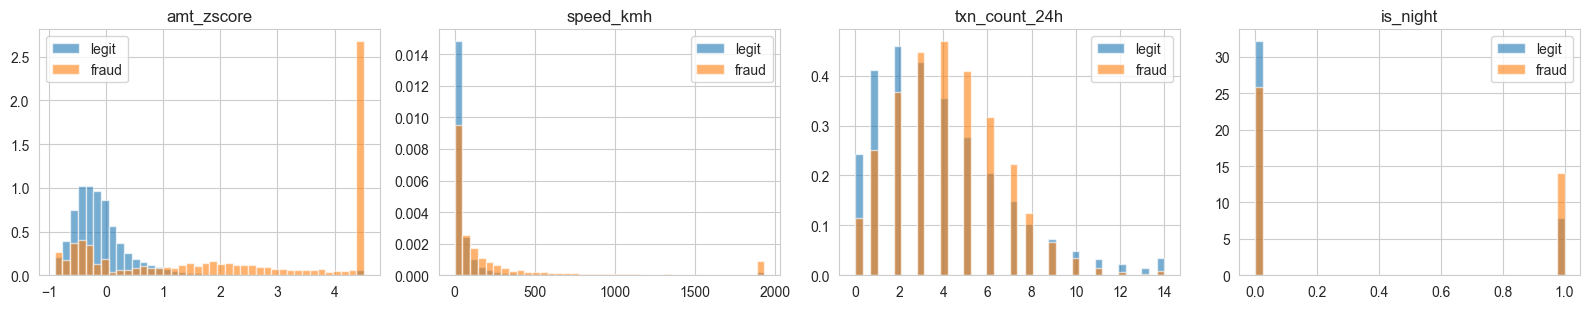

In [4]:
show = ["amt_zscore", "speed_kmh", "txn_count_24h", "is_night"]
fig, axes = plt.subplots(1, len(show), figsize=(16, 3.2))
for ax, col in zip(axes, show):
    lo, hi = np.percentile(X_fit[col], 1), np.percentile(X_fit[col], 99)
    for label, sub in X_fit.groupby(y_fit):
        ax.hist(np.clip(sub[col], lo, hi), bins=40, alpha=0.6, density=True,
                label=("fraud" if label else "legit"))
    ax.set_title(col); ax.legend()
plt.tight_layout(); plt.show()

## 3. Imbalance handling - Approach A vs Approach B

Same base LightGBM under both; only the imbalance treatment differs.

- **A - class weights:** `scale_pos_weight = n_neg / n_pos` (fit fold only).
- **B - SMOTE:** oversample the minority **on the fit fold only**, then train.
  Validation is never resampled.

Decided by **validation PR-AUC**.

In [5]:
# --- Approach A: class weights ---
res_a = train_class_weight(X_fit[FEATURES], y_fit, X_val[FEATURES], y_val,
                           fixed_precision=0.90)

# --- Approach B: SMOTE (training fold only) ---
res_b = train_resampled(X_fit[FEATURES], y_fit, X_val[FEATURES], y_val,
                        method="smote", sampling_strategy=0.1, fixed_precision=0.90)

# --- Approach B': SMOTETomek (a cleaned variant, also fit-fold only) ---
res_bt = train_resampled(X_fit[FEATURES], y_fit, X_val[FEATURES], y_val,
                         method="smotetomek", sampling_strategy=0.1, fixed_precision=0.90)

results = [res_a, res_b, res_bt]
cmp = comparison_table(results)
print("scale_pos_weight =", round(compute_scale_pos_weight(y_fit), 1))
cmp

scale_pos_weight = 172.3


,approach,train_rows,pr_auc,roc_auc,precision,recall,recall@p90
0,class_weight (spw=172.3),1259627,0.9614,0.9989,0.7297,0.9575,0.9275
1,smotetomek (strategy=0.1),1376304,0.9602,0.9992,0.9492,0.8841,0.9130
2,smote (strategy=0.1),1377596,0.9601,0.9991,0.9582,0.8860,0.9121


### Comparison table - class weights vs SMOTE (validation)

In [6]:
display(cmp)

best = pick_best(results)
print(f"\n>>> Winner by validation PR-AUC: {best.name}  "
      f"(PR-AUC = {best.metrics['pr_auc']:.4f})")

,approach,train_rows,pr_auc,roc_auc,precision,recall,recall@p90
0,class_weight (spw=172.3),1259627,0.9614,0.9989,0.7297,0.9575,0.9275
1,smotetomek (strategy=0.1),1376304,0.9602,0.9992,0.9492,0.8841,0.9130
2,smote (strategy=0.1),1377596,0.9601,0.9991,0.9582,0.8860,0.9121



>>> Winner by validation PR-AUC: class_weight (spw=172.3)  (PR-AUC = 0.9614)


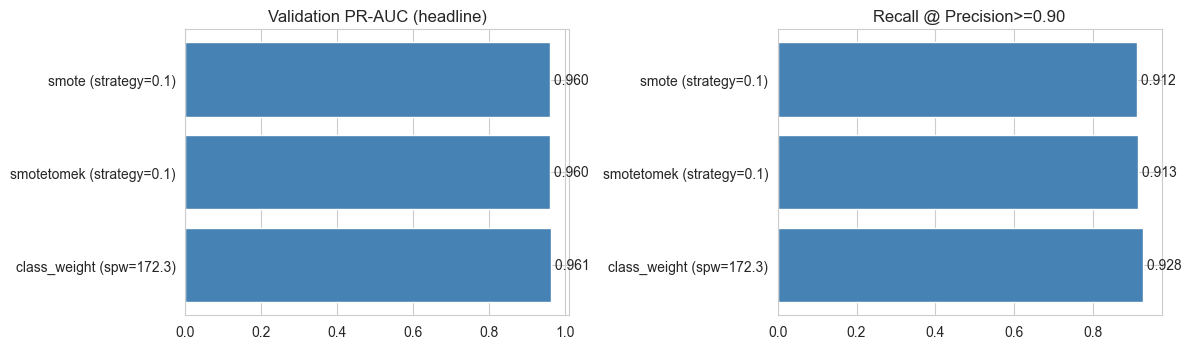

In [7]:
# Visual: PR-AUC and recall@p90 side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, metric, title in zip(axes, ["pr_auc", "recall@p90"],
                             ["Validation PR-AUC (headline)", "Recall @ Precision>=0.90"]):
    ax.barh(cmp["approach"], cmp[metric], color="steelblue", edgecolor="white")
    ax.set_title(title)
    for i, v in enumerate(cmp[metric]):
        ax.text(v, i, f" {v:.3f}", va="center")
plt.tight_layout(); plt.show()

## 4. Confirm the winner on the untouched TEST set

The test split was never used for model selection. We refit the winning strategy
on **fit + val** (all available training data, still strictly before test) and
report final test metrics - the number Phase 3 must beat.

In [8]:
# Combine fit+val for the final model (all data before test).
X_trainfull = pd.concat([X_fit, X_val], ignore_index=True)
y_trainfull = X_trainfull["is_fraud"]

if best is res_a:
    final = train_class_weight(X_trainfull[FEATURES], y_trainfull,
                               X_test[FEATURES], y_test, fixed_precision=0.90)
else:
    method = "smotetomek" if best is res_bt else "smote"
    final = train_resampled(X_trainfull[FEATURES], y_trainfull,
                            X_test[FEATURES], y_test, method=method,
                            sampling_strategy=0.1, fixed_precision=0.90)

print(f"Final strategy: {final.name}")
for k, v in final.metrics.items():
    print(f"  {k:14s}: {v:.4f}")

Final strategy: class_weight (spw=177.5)
  pr_auc        : 0.9713
  roc_auc       : 0.9992
  precision     : 0.6510
  recall        : 0.9733
  recall@p90    : 0.9466


## 5. Conclusion & saved artifacts

The chosen feature set + imbalance strategy are saved to `artifacts/phase2/`
for Phase 3 (Optuna, calibration, threshold tuning, SHAP).

In [9]:
best_method = ("class_weight" if best is res_a
               else "smotetomek" if best is res_bt else "smote")
best_config = ({"scale_pos_weight": round(compute_scale_pos_weight(y_fit), 2)}
               if best is res_a
               else {"method": best_method, "sampling_strategy": 0.1})

categorical_features = ["gender"]  # native LightGBM categorical (others are numeric encodings)

out = save_phase2_artifacts(
    feature_engineer=fe,
    feature_names=FEATURES,
    categorical_features=categorical_features,
    best_strategy=best_method,
    best_strategy_config=best_config,
    comparison_df=cmp,
)
print("Saved Phase-2 artifacts to:", out)
print(" - feature_engineer.joblib  (fitted, train-only encoders)")
print(" - feature_manifest.json    (feature set + chosen strategy)")
print(" - imbalance_comparison.csv (the table above)")

Saved Phase-2 artifacts to: artifacts\phase2
 - feature_engineer.joblib  (fitted, train-only encoders)
 - feature_manifest.json    (feature set + chosen strategy)
 - imbalance_comparison.csv (the table above)


In [10]:
from IPython.display import Markdown

conclusion = f'''
### Written conclusion

**Winner (by validation PR-AUC): `{best.name}`** - PR-AUC **{best.metrics["pr_auc"]:.4f}**.

| | class weights (A) | SMOTE (B) | SMOTETomek (B') |
|---|---|---|---|
| val PR-AUC | {res_a.metrics["pr_auc"]:.4f} | {res_b.metrics["pr_auc"]:.4f} | {res_bt.metrics["pr_auc"]:.4f} |
| val recall@p90 | {res_a.metrics["recall@p90"]:.4f} | {res_b.metrics["recall@p90"]:.4f} | {res_bt.metrics["recall@p90"]:.4f} |

**Why:** For this extreme imbalance (~0.5% fraud), `scale_pos_weight` lets the
gradient-boosted trees reweight the rare class **without inventing synthetic
records**. SMOTE / SMOTETomek interpolate new minority points in a feature space
full of behavioural / temporal / categorical-encoded columns, where a linear blend
of two frauds is not necessarily itself a realistic fraud - which here slightly
*hurt* ranking quality (PR-AUC) even when it nudged precision up. Class weighting
is also cheaper (no resampling) and simpler to serve.

**Carried to Phase 3:** the {len(FEATURES)}-feature set above + the
**{best_method}** imbalance strategy, saved under `artifacts/phase2/`.
'''
Markdown(conclusion)


### Written conclusion

**Winner (by validation PR-AUC): `class_weight (spw=172.3)`** - PR-AUC **0.9614**.

| | class weights (A) | SMOTE (B) | SMOTETomek (B') |
|---|---|---|---|
| val PR-AUC | 0.9614 | 0.9601 | 0.9602 |
| val recall@p90 | 0.9275 | 0.9121 | 0.9130 |

**Why:** For this extreme imbalance (~0.5% fraud), `scale_pos_weight` lets the
gradient-boosted trees reweight the rare class **without inventing synthetic
records**. SMOTE / SMOTETomek interpolate new minority points in a feature space
full of behavioural / temporal / categorical-encoded columns, where a linear blend
of two frauds is not necessarily itself a realistic fraud - which here slightly
*hurt* ranking quality (PR-AUC) even when it nudged precision up. Class weighting
is also cheaper (no resampling) and simpler to serve.

**Carried to Phase 3:** the 21-feature set above + the
**class_weight** imbalance strategy, saved under `artifacts/phase2/`.
